In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_thirty.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.SIGMOID)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/thirty


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 99.96796793176827
R2 -> -0.037544234809197885
MAPE -> 0.13959009563230362


{'d2_absolute_error_score': 0.008137321391601726,
 'd2_pinball_score': 0.008137321391601726,
 'd2_tweedie_score': -0.037544234809197885,
 'explained_variance_score': 0.05376365598558619,
 'max_error': 414.3719379246388,
 'mean_absolute_error': 69.20970408819488,
 'mean_absolute_percentage_error': 0.13959009563230362,
 'mean_gamma_deviance': 0.031881038941407217,
 'mean_poisson_deviance': 17.593118396216475,
 'mean_squared_error': 9993.59461240705,
 'mean_squared_log_error': 0.037216079589196906,
 'median_absolute_error': 43.74539850132135,
 'r2_score': -0.037544234809197885,
 'root_mean_squared_error': 99.96796793176827,
 'root_mean_squared_log_error': 0.19291469510951442}

Plots:

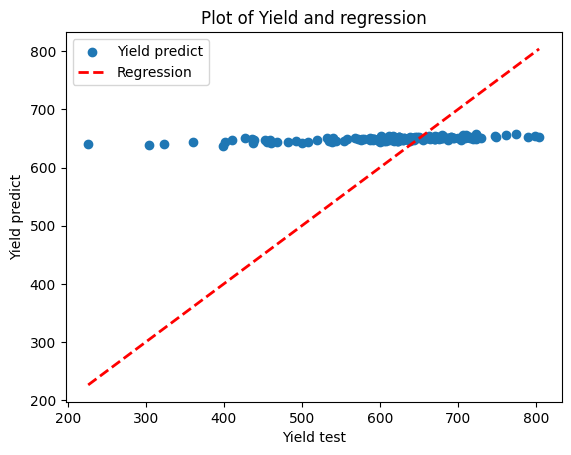

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118,
  'predict': 640.4837379246388,
  'error': 1.8325975819246887},
 {'truth': 304.5419,
  'predict': 639.4229201241354,
  'error': 1.0996221542064835},
 {'truth': 322.9881,
  'predict': 641.1631363955051,
  'error': 0.9850983252804212},
 {'truth': 360.0, 'predict': 643.6101008275979, 'error': 0.7878058356322163},
 {'truth': 400.8056,
  'predict': 644.6686521209567,
  'error': 0.6084322477554123},
 {'truth': 398.2896,
  'predict': 637.8643809710313,
  'error': 0.6015090049326703},
 {'truth': 409.865, 'predict': 646.7375586849673, 'error': 0.5779282414574733},
 {'truth': 427.0, 'predict': 651.2806698847481, 'error': 0.5252474704560847},
 {'truth': 436.0, 'predict': 649.6204657480647, 'error': 0.4899551966698732},
 {'truth': 438.9351, 'predict': 646.8241103674601, 'error': 0.473621294736876},
 {'truth': 437.0, 'predict': 642.9603257307635, 'error': 0.4713050932054086},
 {'truth': 453.0, 'predict': 646.6189523210763, 'error': 0.42741490578604047},
 {'truth': 455.805, 'pre